In [19]:
from util import go_to_project_root
go_to_project_root()

CWD changed to the project root: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1


# Pregunta 4

In [20]:
import numpy as np
import matplotlib.pyplot as plt 

from source.models.arma import ARMA
from source.utils import plot as uplot 
from source.data.loaders import create_dataset
from source.optimize.conditionalss import conditional_square_sum
from source.optimize.likelihood import maximum_likelihood_estimation
from source.optimize.parallel import parallel_bootstrap_hr
from source.utils.plot import plot_forecast

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
dataset = create_dataset('./data/hmw1_25.txt', problem=4)

[INFO] Data loaded successfully!


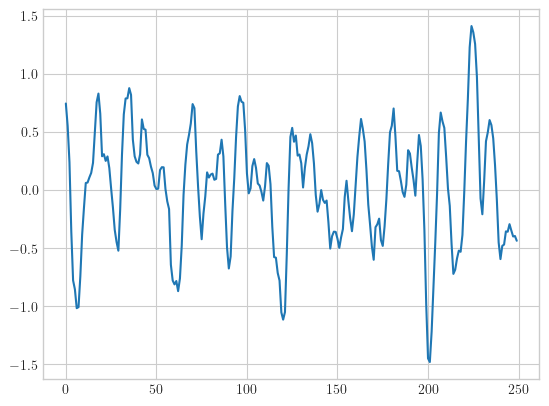

In [24]:
plt.plot(dataset[:, 0])

In [ ]:
criteria = 'hqic' # hqic bic aic
results_0 = parallel_bootstrap_hr(dataset[:, 0], 
                                  iterations=30, 
                                  j_max=20, 
                                  criteria=criteria,
                                  n_jobs=8)

results_1 = parallel_bootstrap_hr(dataset[:, 1], 
                                    iterations=30, 
                                    j_max=20, 
                                    criteria=criteria,
                                    n_jobs=8)

results_2 = parallel_bootstrap_hr(dataset[:, 2], 
                                    iterations=30, 
                                    j_max=20, 
                                    criteria=criteria,
                                    n_jobs=8)

Iniciando Bootstrap con 30 iteraciones...


Procesando iteraciones: 100%|██████████| 30/30 [00:05<00:00,  5.07it/s]



Par más estable: (2,0) [30/30 veces]
Reajustando el modelo final a los datos originales...
Iniciando Bootstrap con 30 iteraciones...


Procesando iteraciones: 100%|██████████| 30/30 [00:01<00:00, 29.14it/s]



Par más estable: (1,1) [21/30 veces]
Reajustando el modelo final a los datos originales...
Iniciando Bootstrap con 30 iteraciones...


Procesando iteraciones: 100%|██████████| 30/30 [00:01<00:00, 24.80it/s]



Par más estable: (0,1) [25/30 veces]
Reajustando el modelo final a los datos originales...


/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:389: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=all_p, ax=axes[0], color='darkblue', linewidth=2.5, fill=True, alpha=0.1)
/home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1/source/utils/plot.py:400: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=all_q, ax=axes[1], color='darkblue', linewidth=2.5, fill=True, alpha=0.1)


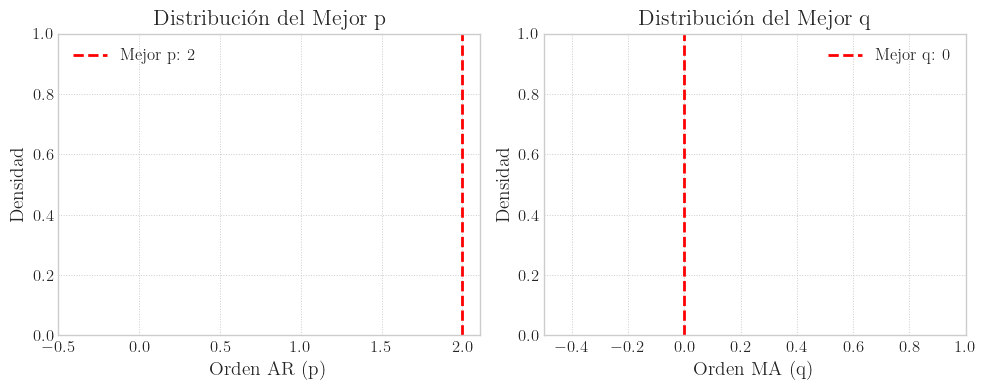

✅ Successfully saved figure to ./presentation/figures/p4/pq_hqic_ipc.pdf


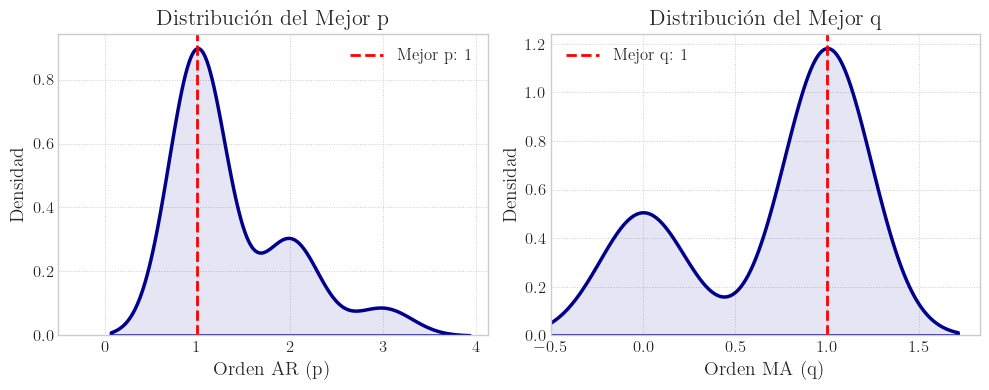

✅ Successfully saved figure to ./presentation/figures/p4/pq_hqic_imacec.pdf


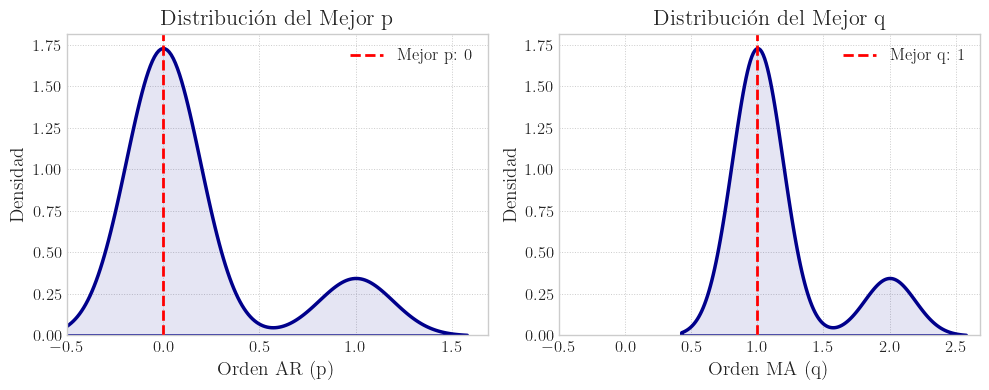

✅ Successfully saved figure to ./presentation/figures/p4/pq_hqic_tpm.pdf


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_0, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p4/pq_{}_ipc.pdf'.format(criteria))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_1, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p4/pq_{}_imacec.pdf'.format(criteria))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_2, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p4/pq_{}_tpm.pdf'.format(criteria))

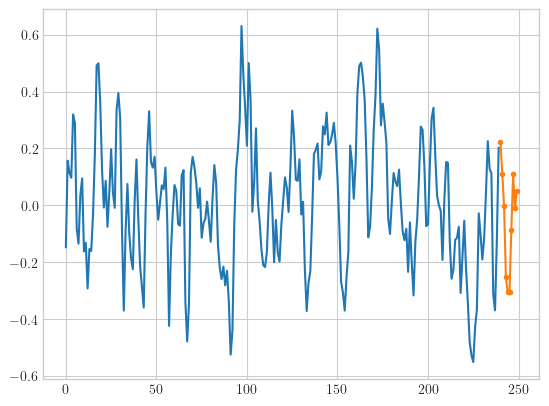

In [33]:
times = np.arange(len(dataset[:, 1]))

x_train = dataset[:-10, 1]
t_train = times[:-10]
x_test = dataset[-10:, 1]
t_test = times[-10:]

plt.plot(t_train, x_train)
plt.plot(t_test, x_test, marker='.')

In [34]:
pi_pred, pi_low, pi_up = results_1['model'].forecast_arma(x_train, h=10)

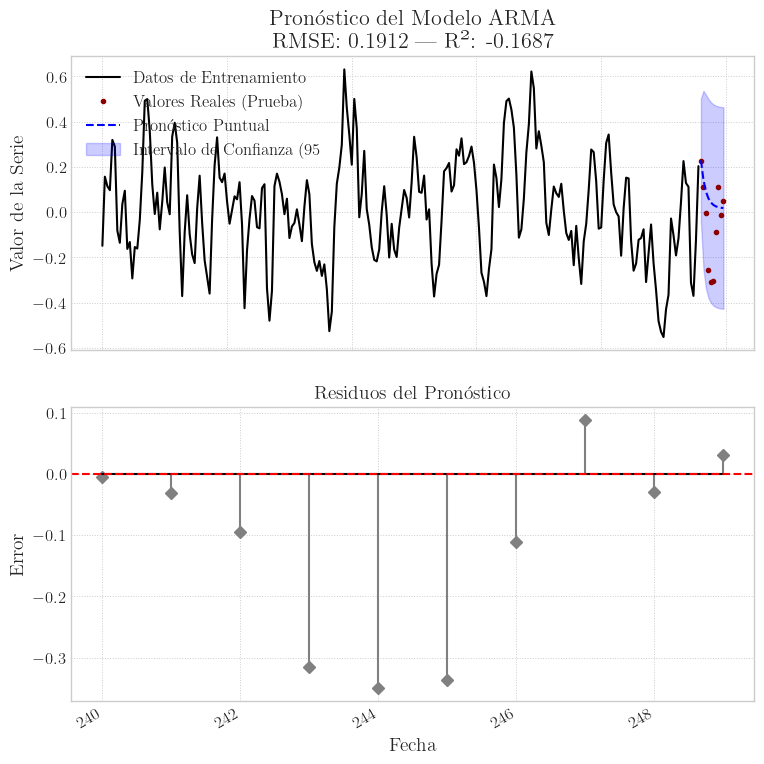

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
fig, axes = plot_forecast(t_train, 
              x_train,
              t_test,
              x_test,
              pi_pred,
              pi_low,
              pi_up, 
              model_name="ARMA", fig=fig, axes=axes)